# Exoplanet Classification and Habitability Analysis

**Author:** Owen Burlingham  
**Dataset:** NASA Exoplanet Archive (6,147 confirmed planets)

## Project Overview

This analysis explores patterns in exoplanet discoveries, examining relationships between planet types, host star characteristics, and potential habitability. Using classification systems and PCA, I investigate how selection bias in discovery methods affects our understanding of planetary systems.

## Key Questions

1. Do different types of stars host different types of planets?
2. What are the most common planet and star types, and how does discovery bias affect this?
3. What percentage of planets could potentially be habitable, and around which star types?

## Dataset Description

The NASA Exoplanet Archive contains 6,147 confirmed planets (after removing duplicates from ~40k rows). 

**Key limitations:**
- **Missing data:** 3,162 planets lack mass measurements; 1,531 lack radius data
- **Selection bias:** Larger planets and stars are overrepresented (easier to detect)
- **Discovery method bias:** Transit method (~90% of discoveries) reveals radius better than mass

**Known biases:**
- Hot Jupiters are most common in this dataset despite representing ~1% of actual planets
- Red Dwarfs (believed to be ~75% of all stars) represent only 5.9% of observed host stars
- Smaller, rocky planets are systematically underrepresented

In [6]:
import pandas as pd
from plotnine import *
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib as plt
import numpy as np

## Data Loading and Initial Exploration

Loading from NASA Exoplanet Archive and examining data completeness.

In [7]:
with open("planets.csv", "r") as f:
    for i in range(10):
        print(f.readline())

# This file was produced by the NASA Exoplanet Archive  http://exoplanetarchive.ipac.caltech.edu

# Mon Feb 23 18:16:41 2026

#

# COLUMN pl_name:        Planet Name

# COLUMN hostname:       Host Name

# COLUMN default_flag:   Default Parameter Set

# COLUMN sy_snum:        Number of Stars

# COLUMN sy_pnum:        Number of Planets

# COLUMN discoverymethod: Discovery Method

# COLUMN disc_year:      Discovery Year



In [11]:
pd.set_option("display.max_columns", None)
planets = pd.read_csv('planets.csv', comment="#")

planets = planets.loc[
    planets.groupby('pl_name').apply(
        lambda x: x.notna().sum(axis=1).idxmax()
    )
].reset_index(drop=True)

/var/folders/5f/bxtw6wg93xn9n7zzf1_4h6w00000gn/T/ipykernel_34757/268697624.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [12]:
planets = planets[['pl_name', 'hostname', 'pl_orbper', 'pl_rade', 'pl_bmasse', 'pl_orbeccen', 'pl_eqt','st_mass', 'st_teff', 'st_met', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year']]
planets.head()

,pl_name,hostname,pl_orbper,pl_rade,pl_bmasse,pl_orbeccen,pl_eqt,st_mass,st_teff,st_met,sy_snum,sy_pnum,discoverymethod,disc_year
0,11 Com b,11 Com,326.03,NaN,6165.600000,0.2310,NaN,2.700000,4742.00,-0.3500,2,1,Radial Velocity,2007.0
1,11 UMi b,11 UMi,516.22,NaN,3337.070000,0.0800,NaN,1.800000,4340.00,0.0400,1,1,Radial Velocity,2009.0
2,14 And b,14 And,186.76,NaN,1131.151301,0.0000,NaN,1.780000,4888.00,-0.2100,1,1,Radial Velocity,2008.0
3,14 Her b,14 Her,1766.41,NaN,1541.467774,0.3674,NaN,0.969205,5314.94,0.4052,1,2,Radial Velocity,2002.0
4,16 Cyg B b,16 Cyg B,799.50,NaN,533.930000,0.6890,NaN,1.030000,5747.00,0.0600,3,1,Radial Velocity,1996.0


In [13]:
len(planets)

6107

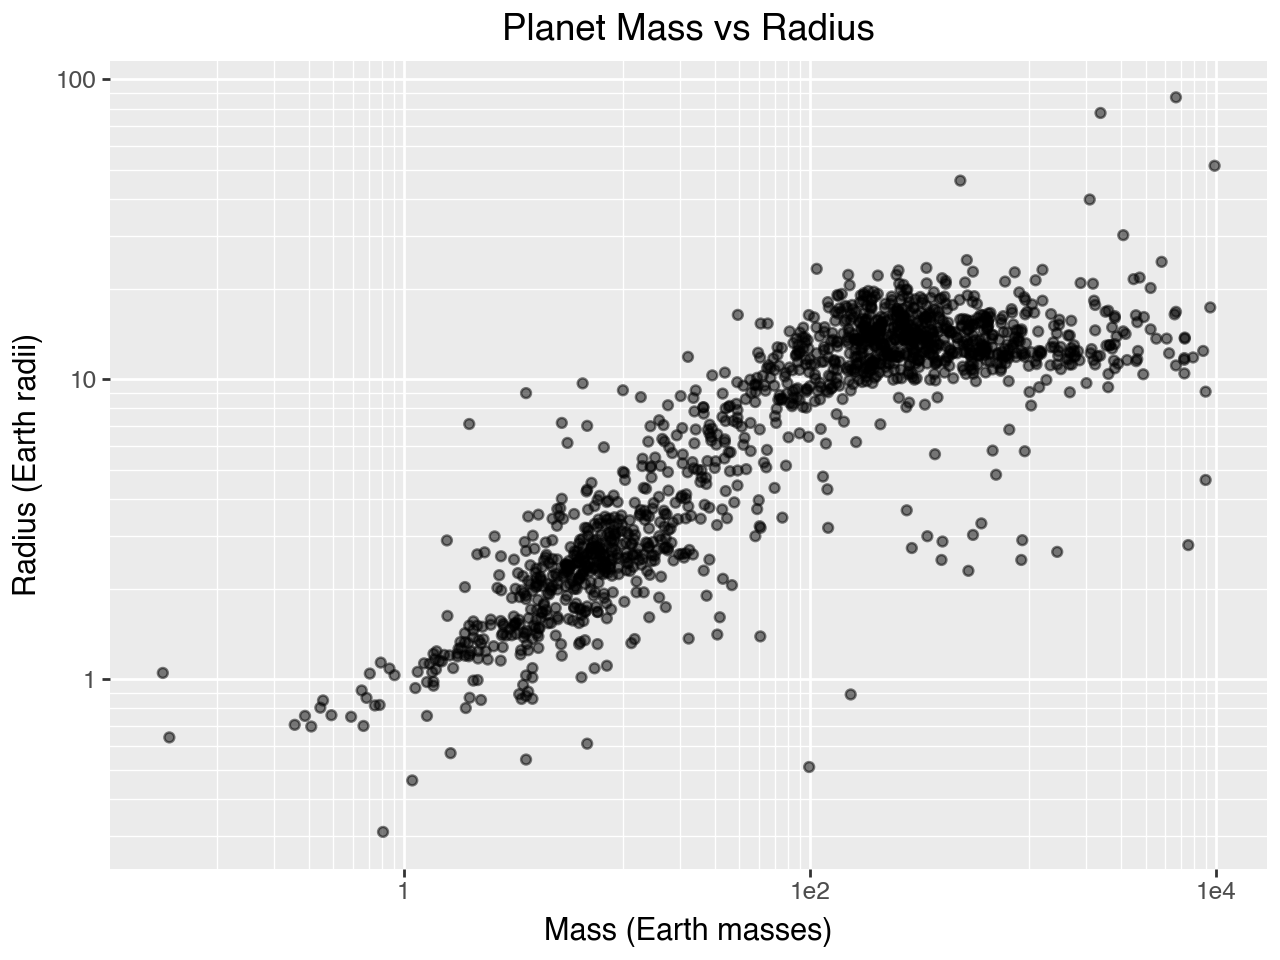

In [29]:
# Mass vs Radius
(ggplot(planets.dropna(subset=['pl_bmasse', 'pl_rade']), 
        aes(x='pl_bmasse', y='pl_rade')) +
 geom_point(alpha=0.5) +
 scale_x_log10() +
 scale_y_log10() +
 labs(title='Planet Mass vs Radius', x='Mass (Earth masses)', y='Radius (Earth radii)'))

### Mass-Radius Relationship

This plot reveals distinct planetary regimes:

- **Lower-left cluster (< 10 Earth masses):** Rocky planets following a tight mass-radius relationship. Density is relatively constant (composition-driven).
- **Upper-right cluster (> 100 Earth masses):** Gas giants with high radius variance at similar masses. "Puffy" hot Jupiters (high radius) vs compressed gas giants (lower radius) reflect different thermal states.
- **Transition zone (10-100 Earth masses):** Neptune-like planets bridging rocky and gaseous compositions.

The two distinct trends confirm that composition fundamentally determines planetary structure—rocky planets compress predictably, while gas giants' radii depend on temperature and atmospheric properties.

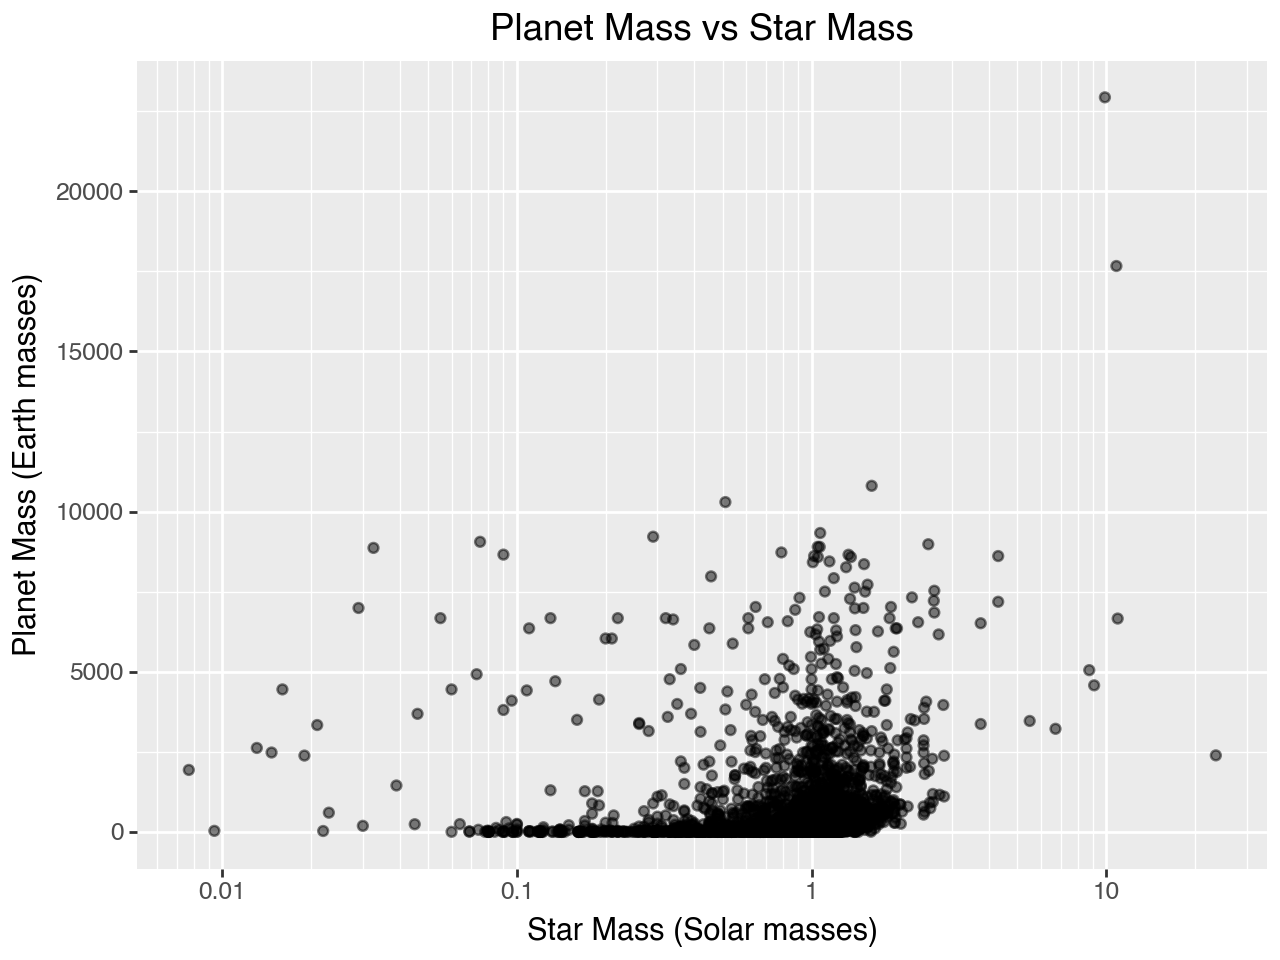

In [32]:
# Planet mass vs Star mass
(ggplot(planets.dropna(subset=['pl_bmasse', 'st_mass']), 
        aes(x='st_mass', y='pl_bmasse')) +
 geom_point(alpha=0.5) +
 scale_x_log10() +
 labs(title='Planet Mass vs Star Mass', x='Star Mass (Solar masses)', y='Planet Mass (Earth masses)'))

### Planet-Star Mass Correlation

Weak positive correlation: more massive stars tend to host more massive planets, though with high scatter.

- **Most planets cluster around Sun-like stars (0.5-1.5 solar masses)** with a wide range of planet masses
- **Low-mass stars (< 0.5 solar masses):** Predominantly host smaller planets (< 1000 Earth masses)
- **High-mass stars (> 2 solar masses):** Can host the most massive planets (> 5000 Earth masses), but are rare

**Interpretation:** Larger protoplanetary disks around massive stars provide more material for planet formation, enabling growth of massive planets. However, detection bias also plays a role—massive planets around massive stars are easier to detect.


## Planet Classification System

Classifying planets by mass and radius-derived density into categories:
- **Earth-like:** Rocky, small (< 2 Earth masses)
- **Super-Earth:** Rocky, larger (2-10 Earth masses)
- **Mega-Earth:** Very large rocky planets
- **Neptune-like:** Gas/ice giants, moderate size
- **Gas Giant:** Large gas planets
- **Hot Jupiter:** Gas giants in close orbits

In [14]:
def classify_planet(row):
    mass = row['pl_bmasse']
    radius = row['pl_rade']

    if pd.isna(mass) or pd.isna(radius):
        return 'Unknown'

    density = mass/(radius ** 3)

    if density > 0.6:
        if mass < 2 and radius < 1.5:
            return 'Earth-like'
        elif mass < 10:
            return 'Super-Earth'
        else:
            return 'Mega-Earth'

    else:  # Low density (< 0.6)
        if radius < 2.5:
            return 'Sub-Neptune'
        elif radius < 4:
            if density > 0.25:  # Denser = more ice/rock
                return 'Mini-Neptune'
            else:
                return 'Low Density Mini-Neptune'
        elif radius < 10:
            if density > 0.2:  # Neptune/Uranus range
                return 'Neptune-like'
            else:
                return 'Saturn-like'  # Lower density gas giant
        else:
            if density < 0.15:
                return 'Inflated Hot Jupiter'
            else:
                return 'Jupiter-like'

planets['planet_type'] = planets.apply(classify_planet, axis = 1)

## Star Classification by Temperature

Categorizing host stars by effective temperature into spectral types:
- Red Dwarf (< 3700K)
- Orange Dwarf (3700-5200K)
- Sun-like (5200-6000K)
- Yellow-White (6000-7500K)
- White (7500-10000K)
- Blue-White (> 10000K)

In [15]:
def classify_star_by_temp(row):
    temp = row['st_teff']
    
    if pd.isna(temp):
        return 'Unknown'
    
    if temp < 2400:
        return 'Brown Dwarf'
    elif temp < 3700:
        return 'Red Dwarf'  # Coolest stars
    elif temp < 5200:
        return 'Orange Dwarf'
    elif temp < 6000:
        return 'Sun-like'  # Sun is ~5800K
    elif temp < 7500:
        return 'Yellow-White'
    elif temp < 10000:
        return 'White'
    elif temp < 30000:
        return 'Blue-White'
    else:
        return 'Blue Giant'  # Hottest stars

planets['star_type'] = planets.apply(classify_star_by_temp, axis=1)

In [16]:
unique_stars = planets.drop_duplicates(subset='hostname')

star_type_counts = unique_stars['star_type'].value_counts()
print("Unique stars by type:")
print(star_type_counts)

star_type_pct = (star_type_counts / star_type_counts.sum() * 100).round(1)
print("\nPercentage of host stars:")
print(star_type_pct)

Unique stars by type:
star_type
Sun-like        1778
Orange Dwarf    1109
Yellow-White     957
Unknown          399
Red Dwarf        267
White             25
Blue-White        11
Brown Dwarf        5
Blue Giant         3
Name: count, dtype: int64

Percentage of host stars:
star_type
Sun-like        39.0
Orange Dwarf    24.4
Yellow-White    21.0
Unknown          8.8
Red Dwarf        5.9
White            0.5
Blue-White       0.2
Brown Dwarf      0.1
Blue Giant       0.1
Name: count, dtype: float64


/var/folders/5f/bxtw6wg93xn9n7zzf1_4h6w00000gn/T/ipykernel_34757/375118435.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


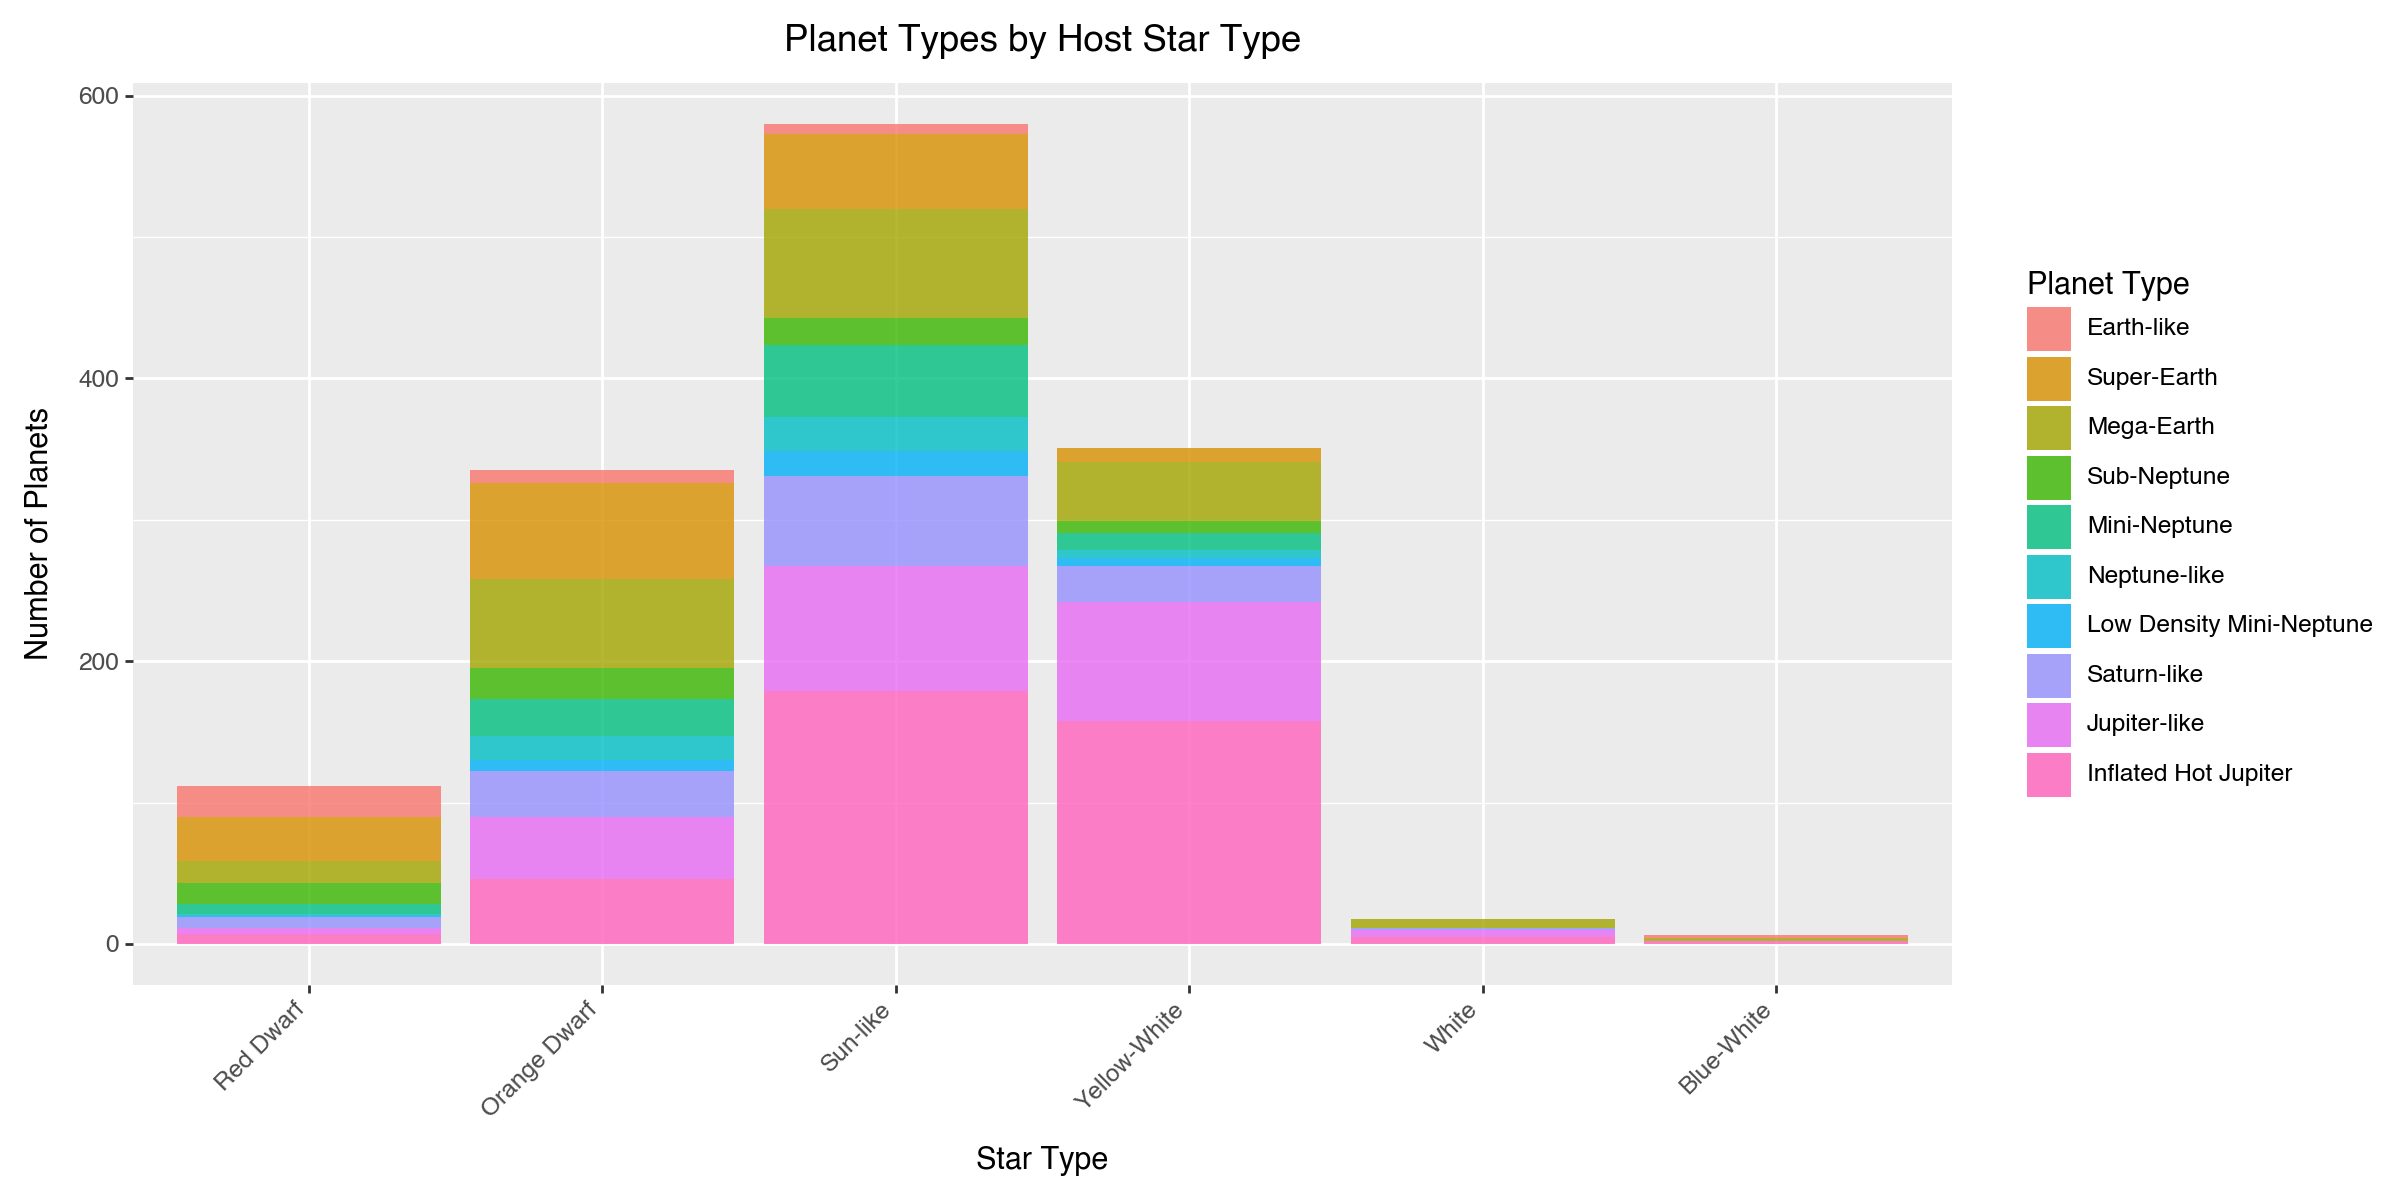

In [17]:
star_type_order = [
    'Red Dwarf',
    'Orange Dwarf', 
    'Sun-like',
    'Yellow-White',
    'White',
    'Blue-White'
]

planet_type_order = [
    'Earth-like',
    'Super-Earth',
    'Mega-Earth',
    'Sub-Neptune',
    'Mini-Neptune',
    'Neptune-like',
    'Low Density Mini-Neptune',
    'Saturn-like',
    'Jupiter-like',
    'Inflated Hot Jupiter'
]

planets['star_type'] = pd.Categorical(
    planets['star_type'],
    categories=star_type_order,
    ordered=True
)

planets['planet_type'] = pd.Categorical(
    planets['planet_type'],
    categories=planet_type_order,
    ordered=True
)

crosstab_df = (planets[planets['planet_type'] != 'Unknown']
               .groupby(['star_type', 'planet_type'])
               .size()
               .reset_index(name='count'))

(ggplot(crosstab_df, aes(x='star_type', y='count', fill='planet_type')) +
 geom_bar(stat='identity', position='stack', alpha=0.8) +
 scale_x_discrete(limits=star_type_order) + 
 scale_fill_discrete(limits=planet_type_order) + 
 labs(title='Planet Types by Host Star Type',
      x='Star Type',
      y='Number of Planets',
      fill='Planet Type') +
 theme(figure_size=(12, 6),
       axis_text_x=element_text(rotation=45, hjust=1)))

### Analysis: Planet Type Distribution by Star Type

**Key finding:** Larger planets tend to orbit larger stars. Red Dwarfs (smallest stars) have the lowest percentage of Hot Jupiters and the highest percentage of Earth-like planets, suggesting they may be more favorable for habitable worlds.

**Important caveat:** This pattern holds despite selection bias. While Hot Jupiters are overrepresented overall, the *ratio* between star types is likely accurate—larger stars genuinely host more massive planets.

In [24]:
# Count planets per star system
planets_per_star = planets.groupby('hostname').agg({
    'pl_name': 'count',  # Number of planets
    'star_type': 'first',  # Star type (same for all planets in system)
    'st_mass': 'first'   # Stellar mass
}).reset_index()

planets_per_star.columns = ['hostname', 'num_planets', 'star_type', 'st_mass']

# Remove unknowns
planets_per_star_clean = planets_per_star[planets_per_star['star_type'] != 'Unknown']

# Calculate average planets per star type
avg_by_star_type = planets_per_star_clean.groupby('star_type')['num_planets'].agg(['mean', 'median', 'max', 'std']).round(2)

print("Average planets per star type:")
print(avg_by_star_type)

Average planets per star type:
              mean  median  max   std
star_type                            
Red Dwarf     1.49     1.0    7  0.92
Orange Dwarf  1.39     1.0    6  0.80
Sun-like      1.38     1.0    6  0.79
Yellow-White  1.29     1.0    8  0.69
White         1.12     1.0    2  0.33
Blue-White    1.45     1.0    3  0.82


/var/folders/5f/bxtw6wg93xn9n7zzf1_4h6w00000gn/T/ipykernel_34757/4259793242.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


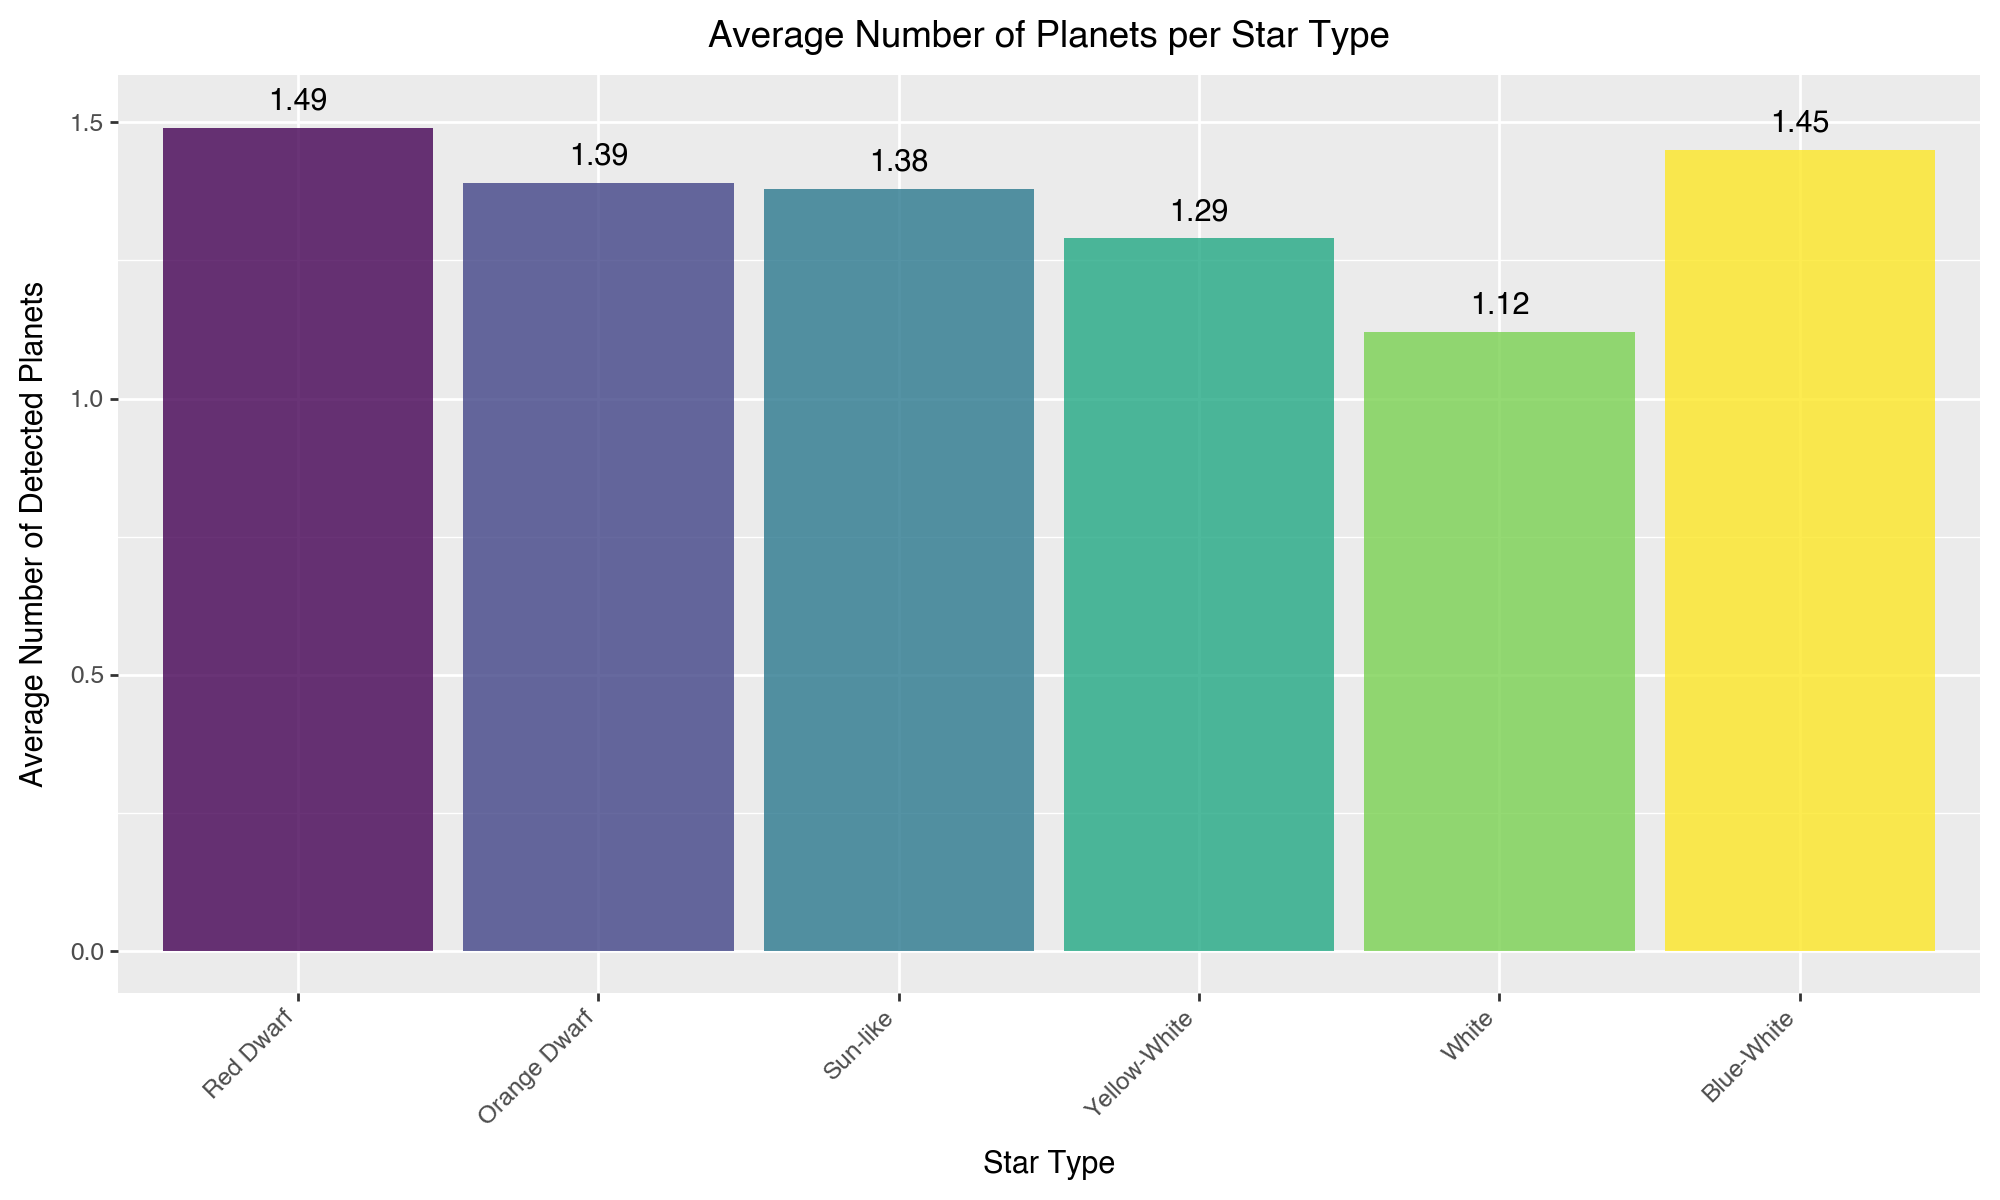

In [25]:
avg_plot_data = avg_by_star_type.reset_index()
avg_plot_data['star_type'] = pd.Categorical(
    avg_plot_data['star_type'],
    categories=star_type_order,
    ordered=True
)

(ggplot(avg_plot_data, aes(x='star_type', y='mean', fill='star_type')) +
 geom_bar(stat='identity', alpha=0.8, show_legend=False) +
 geom_text(aes(label='mean'), format_string='{:.2f}', va='bottom', size=11, nudge_y=0.02) +
 labs(title='Average Number of Planets per Star Type',
      x='Star Type',
      y='Average Number of Detected Planets') +
 theme(figure_size=(10, 6),
       axis_text_x=element_text(rotation=45, hjust=1)))

### Analysis: Multi-Planet Systems

**Surprising result:** All star types average 1.12-1.49 planets per system—nearly identical across star masses. This suggests larger stars host *larger* planets rather than *more* planets.

**Detection bias note:** Most systems show only one detected planet. This may reflect detection limits rather than actual system architecture.

## Principal Component Analysis

Analyzing variance in four planetary variables: orbital period, radius, mass, and eccentricity.

In [18]:
planet_only_vars = ['pl_orbper', 'pl_rade', 'pl_bmasse', 'pl_orbeccen']

pca_data_planets = planets[planet_only_vars].dropna()

print(f"PCA on {len(pca_data_planets)} planets with complete planetary data")

scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data_planets)

pca_planets = PCA()
pca_transformed_planets = pca_planets.fit_transform(pca_data_scaled)

pca_planets_df = pd.DataFrame(
    pca_transformed_planets[:, :2],
    columns=['PC1', 'PC2'],
    index=pca_data_planets.index
)

pca_planets_df['planet_type'] = planets.loc[pca_data_planets.index, 'planet_type']
pca_planets_df['star_type'] = planets.loc[pca_data_planets.index, 'star_type']

print(f"\nPC1: {pca_planets.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca_planets.explained_variance_ratio_[1]*100:.1f}%")

pca_planets_clean = pca_planets_df[
    (pca_planets_df['PC1'].abs() < 10) & 
    (pca_planets_df['PC2'].abs() < 10) &
    (pca_planets_df['star_type'] != 'Unknown')
]

print(f"After removing outliers: {len(pca_planets_clean)} planets")

PCA on 1206 planets with complete planetary data

PC1: 35.6%
PC2: 26.3%
After removing outliers: 1205 planets


/var/folders/5f/bxtw6wg93xn9n7zzf1_4h6w00000gn/T/ipykernel_34757/3806562124.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


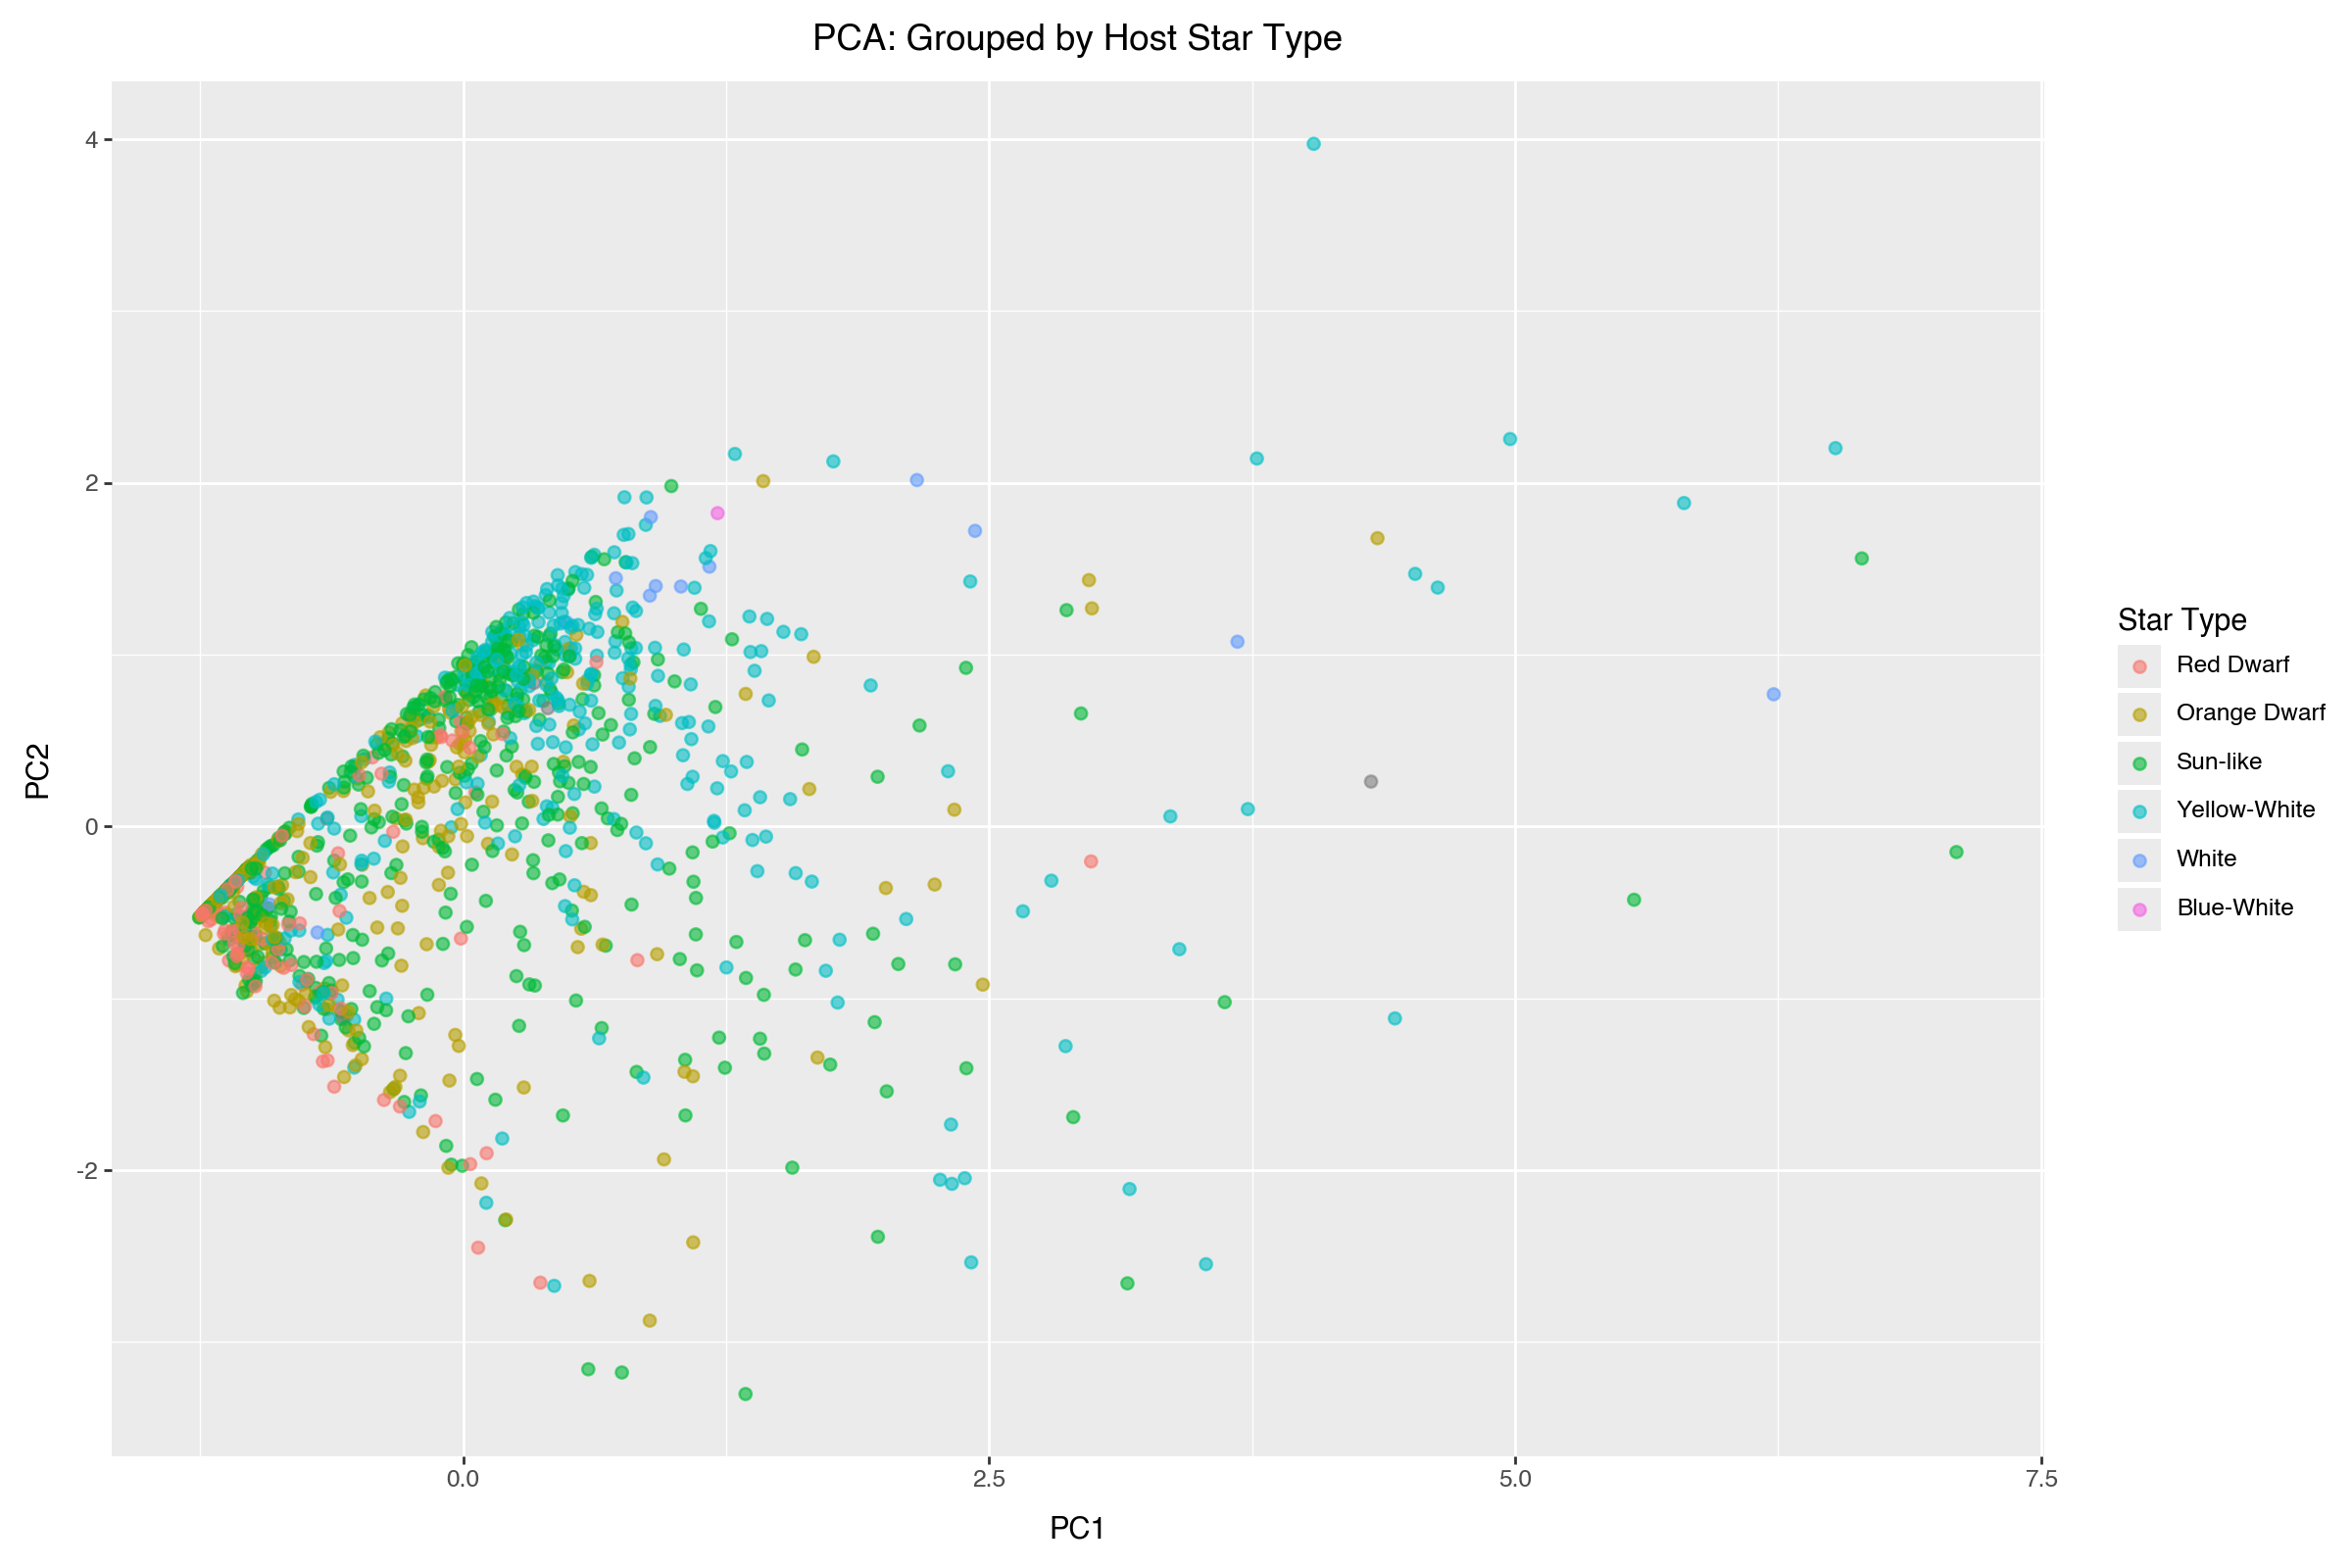

In [19]:

pca_planets_clean['star_type'] = pd.Categorical(
    pca_planets_clean['star_type'],
    categories=star_type_order,
    ordered=True
)

pca_planets_clean = pca_planets_df[
    (pca_planets_df['PC1'].abs() < 10) & 
    (pca_planets_df['PC2'].abs() < 10) &
    (pca_planets_df['star_type'] != 'Unknown')
]

(ggplot(pca_planets_clean, 
        aes(x='PC1', y='PC2', color='star_type')) +
 geom_point(alpha=0.6, size=2) +
 scale_color_discrete(limits=star_type_order) + 
 labs(title='PCA: Grouped by Host Star Type',
      x='PC1',
      y='PC2',
      color='Star Type') +
 theme(figure_size=(12, 8)))

/var/folders/5f/bxtw6wg93xn9n7zzf1_4h6w00000gn/T/ipykernel_34757/62366008.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/5f/bxtw6wg93xn9n7zzf1_4h6w00000gn/T/ipykernel_34757/62366008.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


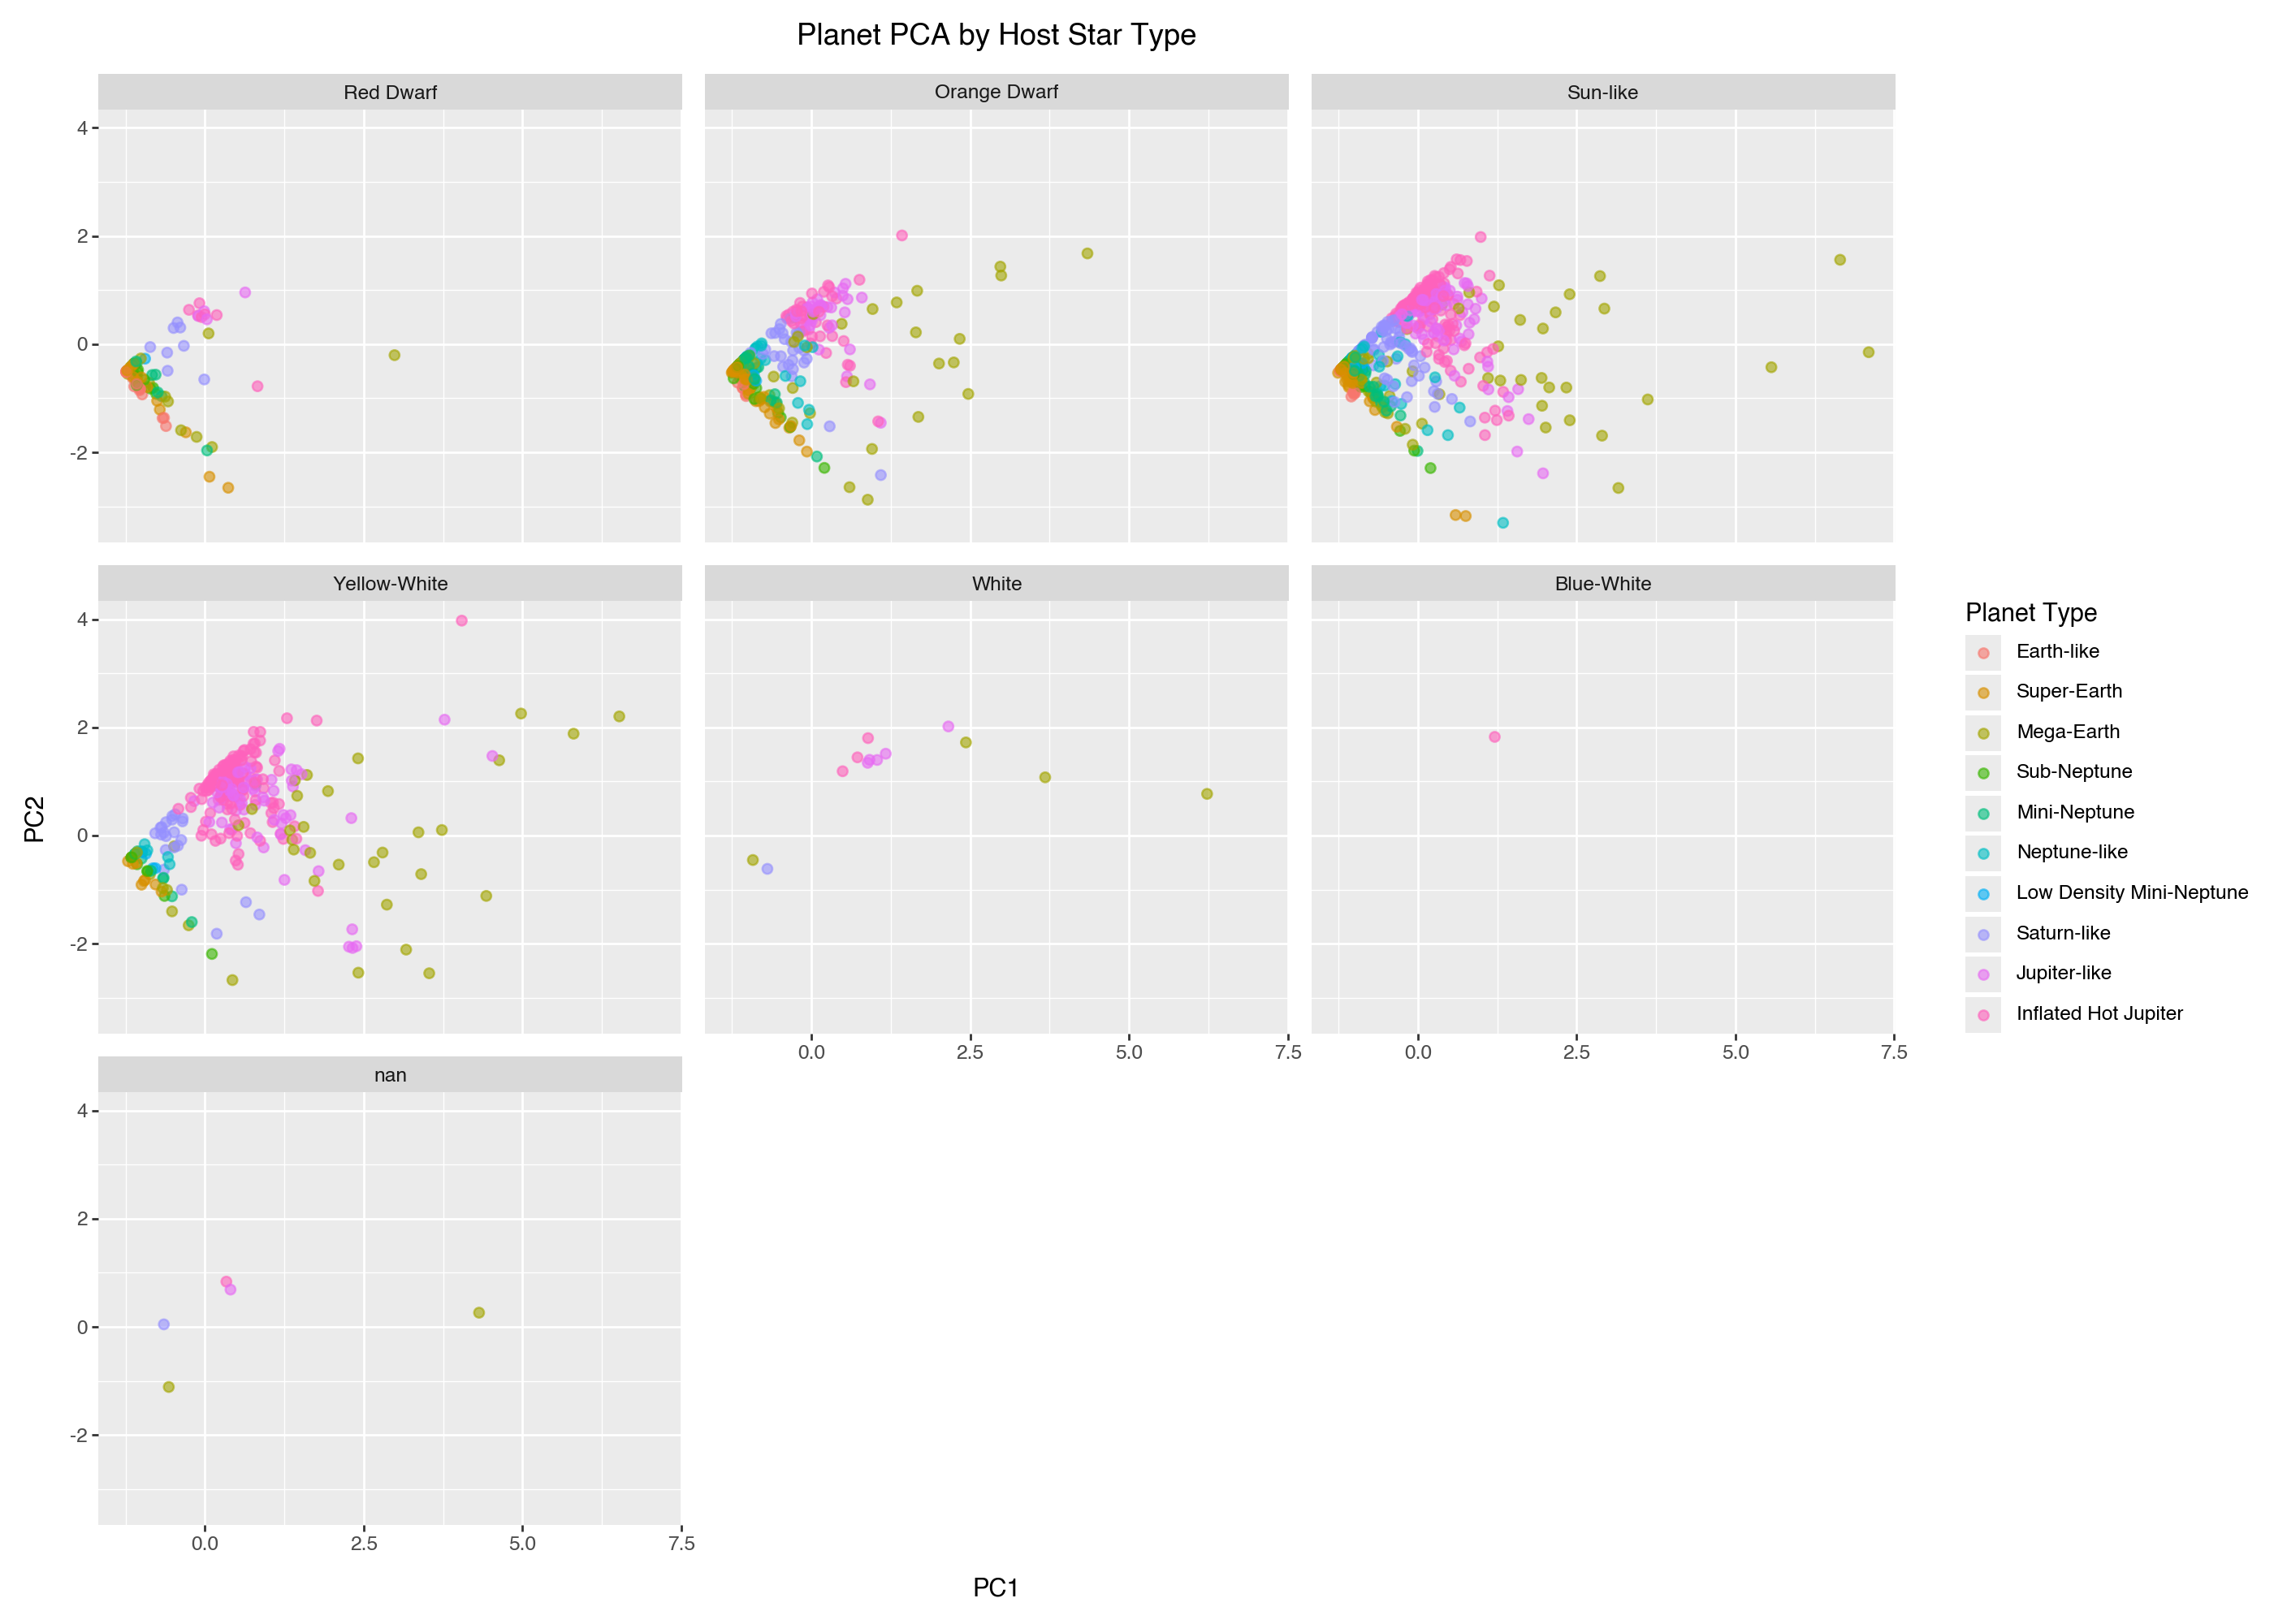

In [20]:
pca_planets_clean['star_type'] = pd.Categorical(
    pca_planets_clean['star_type'],
    categories=star_type_order,
    ordered=True
)

pca_planets_clean['planet_type'] = pd.Categorical(
    pca_planets_clean['planet_type'],
    categories=planet_type_order,
    ordered=True
)

(ggplot(pca_planets_clean, 
        aes(x='PC1', y='PC2', color='planet_type')) +
 geom_point(alpha=0.6, size=2) +
 facet_wrap('~star_type', ncol=3) +
 scale_color_discrete(limits=planet_type_order) +  # Order legend
 labs(title='Planet PCA by Host Star Type',
      x='PC1',
      y='PC2',
      color='Planet Type') +
 theme(figure_size=(14, 10)))

### PCA Interpretation

**PC1 (36.9% variance):** Dominated by planet mass (0.661), with contributions from radius (0.508), orbital period (0.368), and eccentricity (0.412). Represents overall system scale—massive planets in wide, eccentric orbits.

**PC2 (26.1% variance):** Contrasts orbital distance (-0.558) and eccentricity (-0.532) against radius (0.614). Separates migrated hot Jupiters (large planets, close circular orbits) from planets formed in place (smaller, distant, eccentric).

**Visual pattern:** The "L-shaped" boundary in PCA space reveals strict physical constraints—given any planetary characteristic, there are hard limits on what the others can be (e.g., maximum radius for a given mass).

**Star type separation:** More massive planets (positive PC1/PC2) cluster with more massive host stars, confirming earlier bar chart findings.

In [21]:
def classify_habitability(row):
    mass = row['pl_bmasse']
    radius = row['pl_rade']
    period = row['pl_orbper']
    star_type = row['star_type']
    
    if pd.isna(mass) or pd.isna(radius) or pd.isna(period):
        return 'Unknown'
    
    if radius == 0:
        return 'Unknown'
    
    density = mass / (radius ** 3)
    
    is_rocky = density > 0.6
    is_earth_sized = (0.5 < mass < 10) and (0.5 < radius < 2.5)
    in_hz = 200 < period < 500
    good_star = star_type in ['Sun-like', 'Orange Dwarf', 'Yellow-White']
    
    if is_rocky and is_earth_sized and in_hz and good_star:
        return 'Potentially Habitable'
    else:
        return 'Not Habitable'

planets['habitability'] = planets.apply(classify_habitability, axis=1)

total = len(planets[planets['habitability'] != 'Unknown'])
habitable = len(planets[planets['habitability'] == 'Potentially Habitable'])
pct = (habitable / total) * 100

print(f"Potentially Habitable: {habitable} out of {total} ({pct:.2f}%)")

hab_planet = planets[planets['habitability'] == 'Potentially Habitable']
if len(hab_planet) > 0:
    print("\nThe potentially habitable planet:")
    print(hab_planet[['pl_name', 'hostname', 'star_type']].to_string(index=False))

Potentially Habitable: 1 out of 1403 (0.07%)

The potentially habitable planet:
    pl_name  hostname star_type
Kepler-22 b Kepler-22  Sun-like


## Habitability Assessment

Using conservative Earth-similarity criteria:
- Density ≥ 0.6 (rocky composition)
- Mass: 0.5-10× Earth
- Radius: 0.5-2.5× Earth  
- Orbital period: 200-500 days (habitable zone)
- Star type: Sun-like, Orange Dwarf, or Yellow-White (stable, appropriate luminosity)

**Result:** 1 potentially habitable planet found: **Kepler-22b** (a known candidate)

**Extrapolation:** If 1/1403 planets are habitable:
- ~228 million habitable planets in our galaxy
- ~456 quintillion in the observable universe

**Critical note:** This is likely a *lower bound*—small rocky planets are underrepresented in the data due to detection bias. Including Earth would nearly double the estimate.

## Conclusions

### Main Findings

1. **Mass-star correlation:** More massive planets systematically orbit more massive stars
2. **Physical constraints:** Strict correlations between planetary variables create hard boundaries in parameter space (visible in PCA)
3. **System architecture:** Stars average ~1.2-1.4 detected planets per system across all spectral types
4. **Habitability:** Potentially habitable planets are rare in this sample (0.07%), but galaxy-scale extrapolation suggests hundreds of millions exist

### Methodological Limitations

This analysis is constrained by systematic observational biases:
- Large planets overrepresented (easier to detect)
- Small rocky planets underrepresented (harder to detect)
- Transit method bias (90% of discoveries) provides radius but not mass
- True planetary distributions likely differ significantly from observed distributions

**Key insight:** While absolute frequencies are biased, *relative patterns* (e.g., planet-star mass correlation) are likely robust.

### Future Directions

- How much does detection bias distort our understanding of planetary demographics?
- Can life exist under conditions different from Earth-like planets?
- What is the true frequency of habitable worlds after correcting for selection effects?

## Technical Skills Demonstrated

- Data cleaning with severe missingness (>50% for key variables)
- Custom classification systems based on astrophysical domain knowledge
- Dimensionality reduction (PCA) and interpretation of loadings
- Multi-level aggregation and system-level analysis
- Critical evaluation of selection bias and methodological limitations